In [4]:
import pandas as pd
import numpy as np
import random
from collections import defaultdict
import warnings
import json
import copy
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact
from IPython.display import display
import importlib
import os

from sklearn import metrics, set_config
from sklearn.metrics import roc_auc_score, auc
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

import torch

import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms

import jp_utils; importlib.reload(jp_utils)
from jp_utils import get_new_cols, drop_useless_cols, load_data, check_filename, write_file, get_hgnc26, set_idx, limit_df

import custom_transformers; importlib.reload(custom_transformers)
from custom_transformers import get_current_cols, RemoveNearlyConstant, MiniCorrelationAnalysis, FilterVariance, WeightedUnivar, SelectFeatures, RemoveRarelyMutated, RemoveLowExpression, CrossDatasetExpressionSurvival

import data_prep; importlib.reload(data_prep)
from data_prep import TCGA, TRACERx, LUNG, prepare_data, Table1, MutationFrequencies, AlignTRACERx, SelectScalers

pd.set_option('display.max_columns', 100); pd.set_option('display.max_rows', 150)

# https://xenabrowser.net/datapages/?cohort=TCGA%20Lung%20Adenocarcinoma%20(LUAD)&removeHub=https%3A%2F%2Fxena.treehouse.gi.ucsc.edu%3A443 
# https://gdc.cancer.gov/about-data/publications/pancanatlas
paths = {
    'luad_pc': 'data/luad_pancan/', 'luad_fh': 'data/luad_fh/', 'luad_xena': 'data/luad_xena/', 
    'combined_xena': 'data/combined_xena/', 'gdc': 'data/gdc/', 'tracerx': 'data/tracerx/', 'models': 'models/'
}
data_path = 'data/'
keep = {
    'luad_fh': { # 3
        'data_clinical_patient': ['patient_id', 'sex', 'race', 'ethnicity', 'primary_site_patient', 'initial_pathologic_dx_year', 'residual_tumor', 'ajcc_staging_edition', 'ajcc_tumor_pathologic_pt', 'ajcc_nodes_pathologic_pn', 'ajcc_metastasis_pathologic_pm', 'ajcc_pathologic_tumor_stage', 'tobacco_smoking_history_indicator', 'smoking_year_started', 'smoking_year_stopped', 'smoking_pack_years', 'ecog_score', 'new_tumor_event_after_initial_treatment', 'age', 'dfs_status', 'dfs_months', 'treatment_outcome_first_course'],
        'data_clinical_sample': ['patient_id', 'sample_id', 'sample_type']
    },
    'luad_pc': { # 2
        'data_clinical_patient': ['patient_id', 'age', 'sex', 'ajcc_pathologic_tumor_stage', 'ajcc_staging_edition', 'days_to_birth', 'ethnicity', 'path_m_stage', 'path_n_stage', 'path_t_stage', 'race', 'dfs_status', 'dfs_months'],
        'data_clinical_sample': ['patient_id', 'sample_id', 'aneuploidy_score', 'msi_score_mantis', 'msi_sensor_score', 'tbl_score', 'tumor_type']
    },
    'luad_xena': { # 1
        'phenotypes': ['sampleid', 'age_at_initial_pathologic_diagnosis', 'anatomic_neoplasm_subdivision', 'days_to_additional_surgery_locoregional_procedure', 'days_to_additional_surgery_metastatic_procedure', 'days_to_birth', 'days_to_new_tumor_event_after_initial_treatment', 'gender', 'lost_follow_up', 'new_neoplasm_event_type', 'number_pack_years_smoked', 'pathologic_m', 'pathologic_n', 'pathologic_t', 'pathologic_stage', 'residual_tumor', 'sample_type', 'stopped_smoking_year', 'system_version', 'tobacco_smoking_history', 'year_of_tobacco_smoking_onset', 'tobacco_smoking_history_indicator', 'year_of_initial_pathologic_diagnosis', 'primary_therapy_outcome_success']
    },
    'combined_xena': { # 7
        'phenotypes': ['sampleid', 'pathology', 'pathology_updated', '_primary_disease', 'age_at_initial_pathologic_diagnosis', 'anatomic_neoplasm_subdivision', 'days_to_additional_surgery_locoregional_procedure', 'days_to_additional_surgery_metastatic_procedure', 'days_to_birth', 'days_to_new_tumor_event_after_initial_treatment', 'gender', 'histological_type', 'lost_follow_up', 'new_neoplasm_event_type', 'number_pack_years_smoked', 'pathologic_m', 'pathologic_n', 'pathologic_t', 'pathologic_stage', 'residual_tumor', 'sample_type', 'stopped_smoking_year', 'system_version', 'tobacco_smoking_history', 'year_of_tobacco_smoking_onset', 'tobacco_smoking_history_indicator', 'year_of_initial_pathologic_diagnosis', 'primary_therapy_outcome_success']
    },
    'gdc': { # luad_gdc_phenotypes 6; cdr 4; followup 5 
        'luad_gdc_phenotypes': ['sample', 'cigarettes_per_day.exposures', 'years_smoked.exposures', 'pack_years_smoked.exposures', 'race.demographic', 'gender.demographic', 'ethnicity.demographic', 'vital_status.demographic', 'age_at_index.demographic', 'days_to_birth.demographic', 'synchronous_malignancy.diagnoses', 'ajcc_pathologic_stage.diagnoses', 'age_at_diagnosis.diagnoses', 'year_of_diagnosis.diagnoses', 'primary_diagnosis.diagnoses', 'ajcc_staging_system_edition.diagnoses', 'ajcc_pathologic_t.diagnoses', 'ajcc_pathologic_n.diagnoses', 'ajcc_pathologic_m.diagnoses','tumor_descriptor.samples', 'sample_type.samples'],
        'cdr': ['bcr_patient_barcode', 'age_at_initial_pathologic_diagnosis', 'gender', 'race', 'ajcc_pathologic_tumor_stage', 'initial_pathologic_dx_year', 'birth_days_to', 'new_tumor_event_type', 'new_tumor_event_dx_days_to', 'dfi', 'dfi.time', 'type', 'vital_status', 'residual_tumor', 'histological_type', 'treatment_outcome_first_course'],
        'followup': ['bcr_patient_barcode', 'gender', 'days_to_birth', 'age_at_initial_pathologic_diagnosis', 'histological_type', 'race', 'ethnicity', 'year_of_initial_pathologic_diagnosis', 'pathologic_t', 'pathologic_m', 'pathologic_n', 'system_version', 'pathologic_stage', 'anatomic_neoplasm_subdivision', 'residual_tumor', 'tobacco_smoking_history', 'number_pack_years_smoked', 'stopped_smoking_year', 'year_of_tobacco_smoking_onset', 'days_to_new_tumor_event_after_initial_treatment', 'new_neoplasm_event_type', 'primary_therapy_outcome_success']
    },
    'tracerx': {
        'clinicohistopathological_data': ['sample_name_cruk', 'tumour_id_muttable_cruk', 'cruk_id', 'is.primary.tumour.tx421', 'histology_per_tumour_id_muttable', 'smoking_status_merged', 'pathologytnm'],
        'TRACERx421_all_patient_df': ['cruk_id', 'tumour_id_muttable_cruk', 'tumour_id_per_patient', 'age', 'sex', 'ethnicity', 'cigs_perday', 'years_smoking', 'packyears', 'smoking_status_merged', 'ecog_ps', 'pathologytnm', 'pt_stage_per_patient', 'pn_stage_per_patient', 'margin_status_per_patient', 'histology_lesion1_merged', 'histology_multi_full', 'recurrence_time_use', 'first_dfs_any_event_rec.or.new.primary', 'first_event_during_followup', 'cens_dfs', 'dfs_time'],
        'TRACERx421_all_tumour_df': ['cruk_id', 'tumour_id_muttable_cruk', 'clinical_sex', 'age', 'ethnicity', 'histology_3', 'smoking_status_merged', 'cigs_perday', 'years_smoking', 'pack_years', 'pathologytnm'],
        'sampleOverview': ['patient_id', 'tumour_id', 'region', 'sampletype', 'sampletypedetail']
    }
}

if 'device' not in globals(): 
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
hgnc = get_hgnc26()
lung1, tcga1, tracerx1 = prepare_data(paths, keep, hgnc, mut_transform='binarize')
lung1.preprocess(presplit=True, fn='tcga_split_mar2', test_size=0.15, valid_size=0.15)
lung1.finalize()

# For mutation features transformation explanation, see justify_mut_transformation.ipynb
# ^ shows it's not count-like in the classical Poisson sense, it's almost binary but a minority have max up to 4–6 (and a couple with higher like 8 or 15)

# tbl1 = Table1(tcga1, tracerx1)
# tbl1.get_tables(tcga_fn='tcga_table1', trcr_fn='trcr_table1')

---- TCGA ----
Expression shape: (510, 17375), Mutation shape: (562, 16184)
All have clinical (otherwise no label):   Expr + Mut = 132   Expr only = 1   Mut only = 2   Clin only = 3
Cutoff used: Median TTR (434.0)
132 patients (66 late, 66 early)

---- TracerX ----
Cutoff used: Predetermined (434.0)
66 patients (30 late, 36 early)

TCGA splits: 92 train, 20 valid, 20 test

Features removed: 0 clin (7 remaining) 39 expr (17086 remaining) 1318 mut (8369 remaining)


In [6]:
set_config(transform_output='pandas')

def apply_base_pipeline(lung, hgnc, data_path, mfreq_cutoff=0.055):
    bp = Pipeline([
        ('drop_const', RemoveNearlyConstant(lung.cols, t=1e-6)),
        ('rare_mut', RemoveRarelyMutated(lung.cols, f=mfreq_cutoff)),
        ('low_expr', RemoveLowExpression(lung.cols, min_expr=1.0, min_frac=0.2, min_var=0.01)), # keep genes with >1 expr in ≥20% samples, variance ≥0.01
        ('expr_var', FilterVariance(lung.cols, coltype='expr', percentile=25)),
        ('corr', MiniCorrelationAnalysis(lung.cols, hgnc, threshold=0.95, data_path=data_path, primary_method='variance', secondary_method='corr count', corr_metric_mut='jaccard', min_mut_positives=3)),
    ])
    bp.fit(lung.tcga_x_train, lung.tcga_y_train)
    xtr, xva, xte, x_trcr = [bp.transform(ds) for ds in [lung.tcga_x_train, lung.tcga_x_valid, lung.tcga_x_test, lung.trcr_x]]
    print()
    return xtr, xva, xte, x_trcr, bp.named_steps['corr'].known_genes

def apply_expr_fs_pipeline1(lung, known_expr, xtrain, xvalid, xtest, trcr_x, k=50, krb=50, method='f', srounds=50, rs=420, sfrac=0.7, load_fn=''):
    cdes = CrossDatasetExpressionSurvival(lung.cols, min_var_target=1e-3, max_abs_zshift=3.5)
    cdes.fit(xtrain, trcr_x)
    xtr, xva, xte, x_trcr = [cdes.transform(ds) for ds in [xtrain, xvalid, xtest, trcr_x]]
    cols = get_current_cols(xtr, lung.cols)
    known_excluded = [g.replace('_expr','') for g in known_expr if g not in cols['expr']]
    print(f" - {len(known_excluded)} known genes excluded due to shift ({sorted(known_excluded)})\n")
    if load_fn == '':
        fs_pipeline = Pipeline([
            ('expr_wuni', WeightedUnivar(lung.cols, coltype='expr', score=method, known_genes=known_expr, k=k, known_rank_bonus=krb, stability_rounds=srounds, stability_frac=sfrac, random_state=rs))
        ])
        fs_pipeline.fit(xtr, lung.tcga_y_train)
        xtr, xva, xte, x_trcr = [fs_pipeline.transform(ds) for ds in [xtr, xva, xte, x_trcr]]
        cols = get_current_cols(xtr, lung.cols)
    else:
        fs_pipeline = None
        temp = load_data('json', load_fn, data_path)
        cols['expr'] = temp['expr']
        xtr, xva, xte, x_trcr = [ds[cols['clin']+cols['expr']+cols['mut']].copy() for ds in [xtr, xva, xte, x_trcr]]
    known_included = [g.replace('_expr','') for g in known_expr if g in cols['expr']]
    print(f"Expression selected = {len(cols['expr'])} ({len(known_included)} known = {sorted(known_included)})\n")
    return xtr, xva, xte, x_trcr, cols, fs_pipeline

def apply_mut_fs_pipeline(lung, cols, known_mut, xtrain, xvalid, xtest, trcr_x, trcr_xa=None, k=50, bf=3.5, rs=42, xgb_params=None, importance_type='total_gain', load_fn=''):
    ddict = {k: v for k, v in zip(['xtr', 'xva', 'xte', 'x_trcr'], [xtrain, xvalid, xtest, trcr_x])}
    if load_fn == '':
        xgb_base = dict(random_state=rs, n_jobs=-1, importance_type=importance_type)
        xgb_default = dict(n_estimators=600, eta=0.05, max_depth=10, min_child_weight=1, subsample=0.8, colsample_bytree=0.5, reg_alpha=0.0, reg_lambda=2.0)
        xgb_use = {**xgb_base, **xgb_params} if xgb_params is not None else {**xgb_base, **xgb_default}
        xgb = XGBClassifier(**xgb_use)
        mutfs = SelectFeatures(lung.cols, coltype='mut', clf=xgb, top_k=k, boost_known=known_mut, boost_factor=bf)
        mutfs.fit(ddict['xtr'], lung.tcga_y_train)
        xtr, xva, xte, x_trcr = [mutfs.transform(ds) for k, ds in ddict.items()]
        x_trcr_a = None if trcr_xa is None else mutfs.transform(trcr_xa)
        cols_new = get_current_cols(xtr, lung.cols)
    else:
        temp = load_data('json', load_fn, data_path)
        cols_new = {'clin': cols['clin'], 'expr': cols['expr'], 'mut': temp['mut']}
        xtr, xva, xte, x_trcr = [ds[cols_new['clin']+cols_new['expr']+cols_new['mut']].copy() for k, ds in ddict.items()]
        x_trcr_a = None if trcr_xa is None else trcr_xa[cols_new['clin']+cols_new['expr']+cols_new['mut']].copy()
    known_included = [g.replace('_mut','') for g in known_mut if g in cols_new['mut']]
    print(f"Mutation selected = {len(cols_new['mut'])} ({len(known_included)} known = {sorted(known_included)})")
    return (xtr, xva, xte, x_trcr, cols_new) if x_trcr_a is None else (xtr, xva, xte, x_trcr, x_trcr_a, cols_new)

mutfreq1 = MutationFrequencies(lung1)
# mutfreq1.plot_retention(.045)

In [7]:
xtr1, xva1, xte1, trcr_x1, known_genes = apply_base_pipeline(lung1, hgnc, data_path, mfreq_cutoff=0.045)
knowndict = {key: [f'{g}_{key}' for g in known_genes] for key in ['expr', 'mut']}
cols = get_current_cols(xtr1, lung1.cols)

RemoveNearlyConstant - features removed: 0 clin  0 expr  0 mut 
RemoveRarelyMutated - 7360 mut removed (mutated in less than 4% of tumors), 1009 mut remaining
RemoveLowExpression - 1377 expr removed (15709 expr remaining)
FilterVariance - 3985 expr removed, 11724 expr remaining
MiniCorrelationAnalysis (within-modality) - removed: 38 expr (11686 remain), 0 mut (1009 remain)



In [8]:
xtr2, xva2, xte2, trcr_x2, cols1, fsp1 = apply_expr_fs_pipeline1(lung1, knowndict['expr'], xtr1, xva1, xte1, trcr_x1, k=50, krb=2000, method='snr', srounds=75, sfrac=0.85, load_fn='columns_mar2')

CrossDatasetExpressionSurvival - 211 expr removed (11475 expr remaining)
 - 36 known genes excluded due to shift (['ABL2', 'ARID1A', 'ARID1B', 'ARID2', 'BIRC6', 'BRAF', 'CCDC174', 'CCDC6', 'CDKN1B', 'CLTC', 'DCTN1', 'DLGAP5', 'GOPC', 'JAK1', 'KDELR2', 'KIF5B', 'KLC1', 'MAP2K1', 'MAP2K5', 'MGAM', 'NFE2L2', 'NRAS', 'PEX3', 'PIK3CA', 'POU4F2', 'PTEN', 'PTPN11', 'RASSF1', 'RB1', 'SETD2', 'TFG', 'TOP1', 'TPM3', 'TPR', 'TRIM33', 'U2AF1'])

Expression selected = 50 (23 known = ['CAT', 'CDKN2A', 'COL1A1', 'FAM83A', 'GCC2', 'GSTM1', 'HES1', 'HIC1', 'HRAS', 'KEAP1', 'MDM2', 'NOTCH3', 'NOTCH4', 'NTRK1', 'PDGFRB', 'PROM1', 'RHOV', 'RIT1', 'SFRP1', 'SLC3A2', 'SMARCA4', 'STK11', 'TPTE'])



In [9]:
domainalign1 = AlignTRACERx(cols1, method='quantile', align_age=True)
trcr_x2a = domainalign1.align_continuous(xtr2, trcr_x2)

selectscalers1 = SelectScalers(xtr2, cols1, to_scale=['clin', 'expr'], outlier_heavy=0.02, many_zeros=0.8) # mut is binary
xtr3, xva3, xte3, trcr_x3, trcr_x3a = selectscalers1.apply_scalers_from_recs(xtr2, xva2, xte2, trcr_x2, trcr_x2a)

In [10]:
xgbp = dict(n_estimators=300, eta=0.05, max_depth=2, min_child_weight=3, subsample=0.8, colsample_bytree=0.6, reg_alpha=1.5, reg_lambda=1.5)
# xtr4, xva4, xte4, trcr_x4, trcr_x4a, cols2 = apply_mut_fs_pipeline(lung1, cols1, knowndict['mut'], xtr3, xva3, xte3, trcr_x3, trcr_xa=trcr_x3a, k=50, bf=4, rs=45678, xgb_params=xgbp, importance_type='gain')
xtr4, xva4, xte4, trcr_x4, trcr_x4a, cols2 = apply_mut_fs_pipeline(lung1, cols1, knowndict['mut'], xtr3, xva3, xte3, trcr_x3, trcr_xa=trcr_x3a, k=50, bf=4, rs=45678, xgb_params=xgbp, importance_type='gain', load_fn='columns_mar2')

Mutation selected = 50 (6 known = ['CTNND2', 'KEAP1', 'KRAS', 'MGAM', 'STK11', 'TP53'])


In [11]:
saved_cols = load_data('json', 'columns_mar2', data_path)
for k in ['clin', 'expr', 'mut']:
    assert saved_cols[k] == cols2[k], f'mismatch in {k}'

ytr, yva, yte, trcr_y = lung1.tcga_y_train, lung1.tcga_y_valid, lung1.tcga_y_test, lung1.trcr_y
datadict1a = {'xtr': xtr4, 'xva': xva4, 'xte': xte4, 'ytr': ytr, 'yva': yva, 'yte': yte, 'trcr_x': trcr_x4a, 'trcr_y': trcr_y} # LUAD aligned

# for k, d in datadict1a.items():
#     d.to_csv(f"processed_data/{k}.csv")

#### **PLASMA**

In [12]:
import train_util; importlib.reload(train_util)
import model; importlib.reload(model)
import hp_tune; importlib.reload(hp_tune)
from train_util import ModelParams, multiseed_train_eval, generate_seeds
from hp_tune import tune_hyperparameters, cross_validate_hparams, best_trial_with_tiebreak
import optuna

def format_results(val_r, tcga_r, trcr_r):
    metric_keys = ['auc', 'auprc', 'avg_prec', 'bal_acc', 'prec', 'rec', 'spec', 'f1', 'tn', 'fp', 'fn', 'tp']
    rows = []
    for rdict in [val_r, tcga_r, trcr_r]:
        rows.append({m: f"{int(rdict[m]):d}" if m in ['tn', 'fp', 'fn', 'tp'] else f"{rdict[m]*100:.2f}" for m in metric_keys})
    return pd.DataFrame(rows, index=['Val TCGA', 'Test TCGA', 'Test TRCR'])

def run_cfg(cfg, cols, dd, seeds, cal_kind='platt', return_all=False, nboot=1000, boot_seed=0, print_thresh=False, strict_determinism=False, pin_memory=True, plot_metrics=False):
    prms = ModelParams(cols, **cfg)
    mte = multiseed_train_eval(prms, dd, device, seeds, cal_kind, nboot, boot_seed, print_thresh, strict_determinism, pin_memory, plot_metrics)
    result_df = format_results(mte['results']['tcga_val']['metrics'], mte['results']['tcga_test']['metrics'], mte['results']['tracerx']['metrics'])
    auc1, rec1, spec1, auc2, rec2, spec2 = [float(result_df.loc[s, m]) for s in ['Test TCGA', 'Test TRCR'] for m in ['auc', 'rec', 'spec']]
    display(result_df[[c for c in result_df.columns.tolist() if c != 'threshold']])
    if return_all: return mte

def plot_loss(mte):
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 3.5), dpi=600, gridspec_kw={'wspace': .25})
    for seed, losses in mte['per_seed_epoch_losses'].items():
        ax1.plot([*range(len(losses['train']))], losses['train'], label=f'seed {seed}', marker='.')
        ax2.plot([*range(len(losses['val']))], losses['val'], label=f'seed {seed}', marker='.')
    for i, ax in enumerate([ax1, ax2]):
        ax.set_xlabel('Epoch', fontsize=10, fontweight=540); ax.set_ylabel('Loss', fontsize=10, fontweight=540)
        ax.set_title(f"PLASMA {['Training', 'Validation'][i]} Loss", fontsize=11, fontweight='bold', pad=5)
        ax.legend(); ax.grid(True)
    plt.show()

seeds5 = generate_seeds(n=5, seed=9999) # [2035, 2583, 1239, 2148, 3188]

STUDIES_DIR = os.environ.get('STUDIES_DIR', 'studies')

seeds = [2035, 2583, 1239, 2148, 3188]


In [13]:
def search0(trial):
    return {
        'clin_opt': dict(lr=trial.suggest_categorical('clin_lr', [.0003, .0001, .0005])),
        'expr_opt': dict(lr=trial.suggest_categorical('expr_lr', [.0003, .0001, .0005])),
        'mut_opt':  dict(lr=trial.suggest_categorical('mut_lr', [.0003, .0001, .0005])),
        'fus_opt':  dict(lr=trial.suggest_categorical('fus_lr', [.0003, .0001, .0005])),
        'es': dict(grace_epochs=trial.suggest_categorical('grace', [8, 10, 12])),
        'sched': dict(factor=trial.suggest_categorical('factor', [.3, .5, .6]), cooldown=trial.suggest_categorical('cool', [0, 1, 2, 3]))
    }

def update0(base, bp):
    new = copy.deepcopy(base)
    for m in ['clin', 'expr', 'mut', 'fus']: new[f'{m}_opt']['lr'] = bp[f'{m}_lr']
    new['es']['grace_epochs'] = bp['grace']
    new['sched'].update({'factor': bp['factor'], 'cooldown': bp['cool']})
    return new

base0 = dict(
    version = 'CEM',
    clin = {'input_drop': 0, 'n': [16], 'out': 16, 'dropout': [.1], 'act': 'gelu', 'norm': False},
    expr = {'input_drop': 0, 'n': [32, 16], 'out': 16, 'dropout': [.3, .1], 'act': 'gelu', 'norm': True},
    mut =  {'input_drop': .1, 'n': [16], 'out': 16, 'dropout': [.2], 'act': 'leaky_relu', 'norm': False},
    fus = {'embed': 16, 'n': [16], 'dropout': [0], 'act': 'leaky_relu'},
    att = {'use': True, 'n_heads': 4, 'dropout': .1},
    aux = {'weight': 0, 'decay': 8},
    mod_dropout = .15,
    clin_opt = {'opt': 'adam', 'lr': .0003, 'weight_decay': .0003},
    expr_opt = {'opt': 'adam', 'lr': .0003, 'weight_decay': .0003},
    mut_opt = {'opt': 'adam', 'lr': .0003, 'weight_decay': .0003},
    fus_opt = {'opt': 'adam', 'lr': .0001, 'weight_decay': .0003},
    es = {'use': True, 'patience': 4, 'metric': 'auc', 'grace_epochs': 10},
    sched = {'patience': 2, 'metric': 'auc', 'factor': .5, 'cooldown': 1},
    max_grad_norm = 1.0,
    threshold_target = 'gmean',
    epochs = 30, bs = 12, restore_best = True,
    use_pos_weight = True
)

stg = f'sqlite:///{STUDIES_DIR}/0.db'
# result0 = tune_hyperparameters(datadict1a, cols2, device, storage=stg, n_trials=80, k=3, n_seeds_per_fold=5, n_startup_trials=30, inner_val_frac=0.15, seed=9999, base_overrides=base0, search_space=search0, verbose=True, study_name='0')
study = optuna.load_study(study_name='0', storage=stg)
result0 = {'study': study, 'best_value': float(study.best_value), 'best_params': dict(study.best_params)}
print(result0['best_value'], result0['best_params'])
best, meta = best_trial_with_tiebreak(result0['study'], secondary='fold_std', return_meta=True)
print(meta); print(best.params)

0.5465681748230226 {'clin_lr': 0.0003, 'expr_lr': 0.0005, 'mut_lr': 0.0001, 'fus_lr': 0.0003, 'grace': 12, 'factor': 0.6, 'cool': 2}
{'top_value': 0.5465681748230226, 'tol': 1e-06, 'n_tied': 22, 'tied_numbers': [47, 48, 49, 51, 52, 53, 54, 56, 58, 59, 61, 62, 63, 64, 65, 70, 71, 72, 73, 74, 75, 76], 'secondary': 'fold_std', 'chosen_number': 47}
{'clin_lr': 0.0003, 'expr_lr': 0.0005, 'mut_lr': 0.0001, 'fus_lr': 0.0003, 'grace': 12, 'factor': 0.6, 'cool': 2}


,auc,auprc,avg_prec,bal_acc,prec,rec,spec,f1,tn,fp,fn,tp
Val TCGA,57.00,59.94,62.66,70.00,75.00,60.00,80.00,66.67,8,2,4,6
Test TCGA,85.00,87.94,88.46,80.00,80.00,80.00,80.00,80.00,8,2,2,8
Test TRCR,76.48,79.55,79.95,71.11,83.33,55.56,86.67,66.67,26,4,16,20


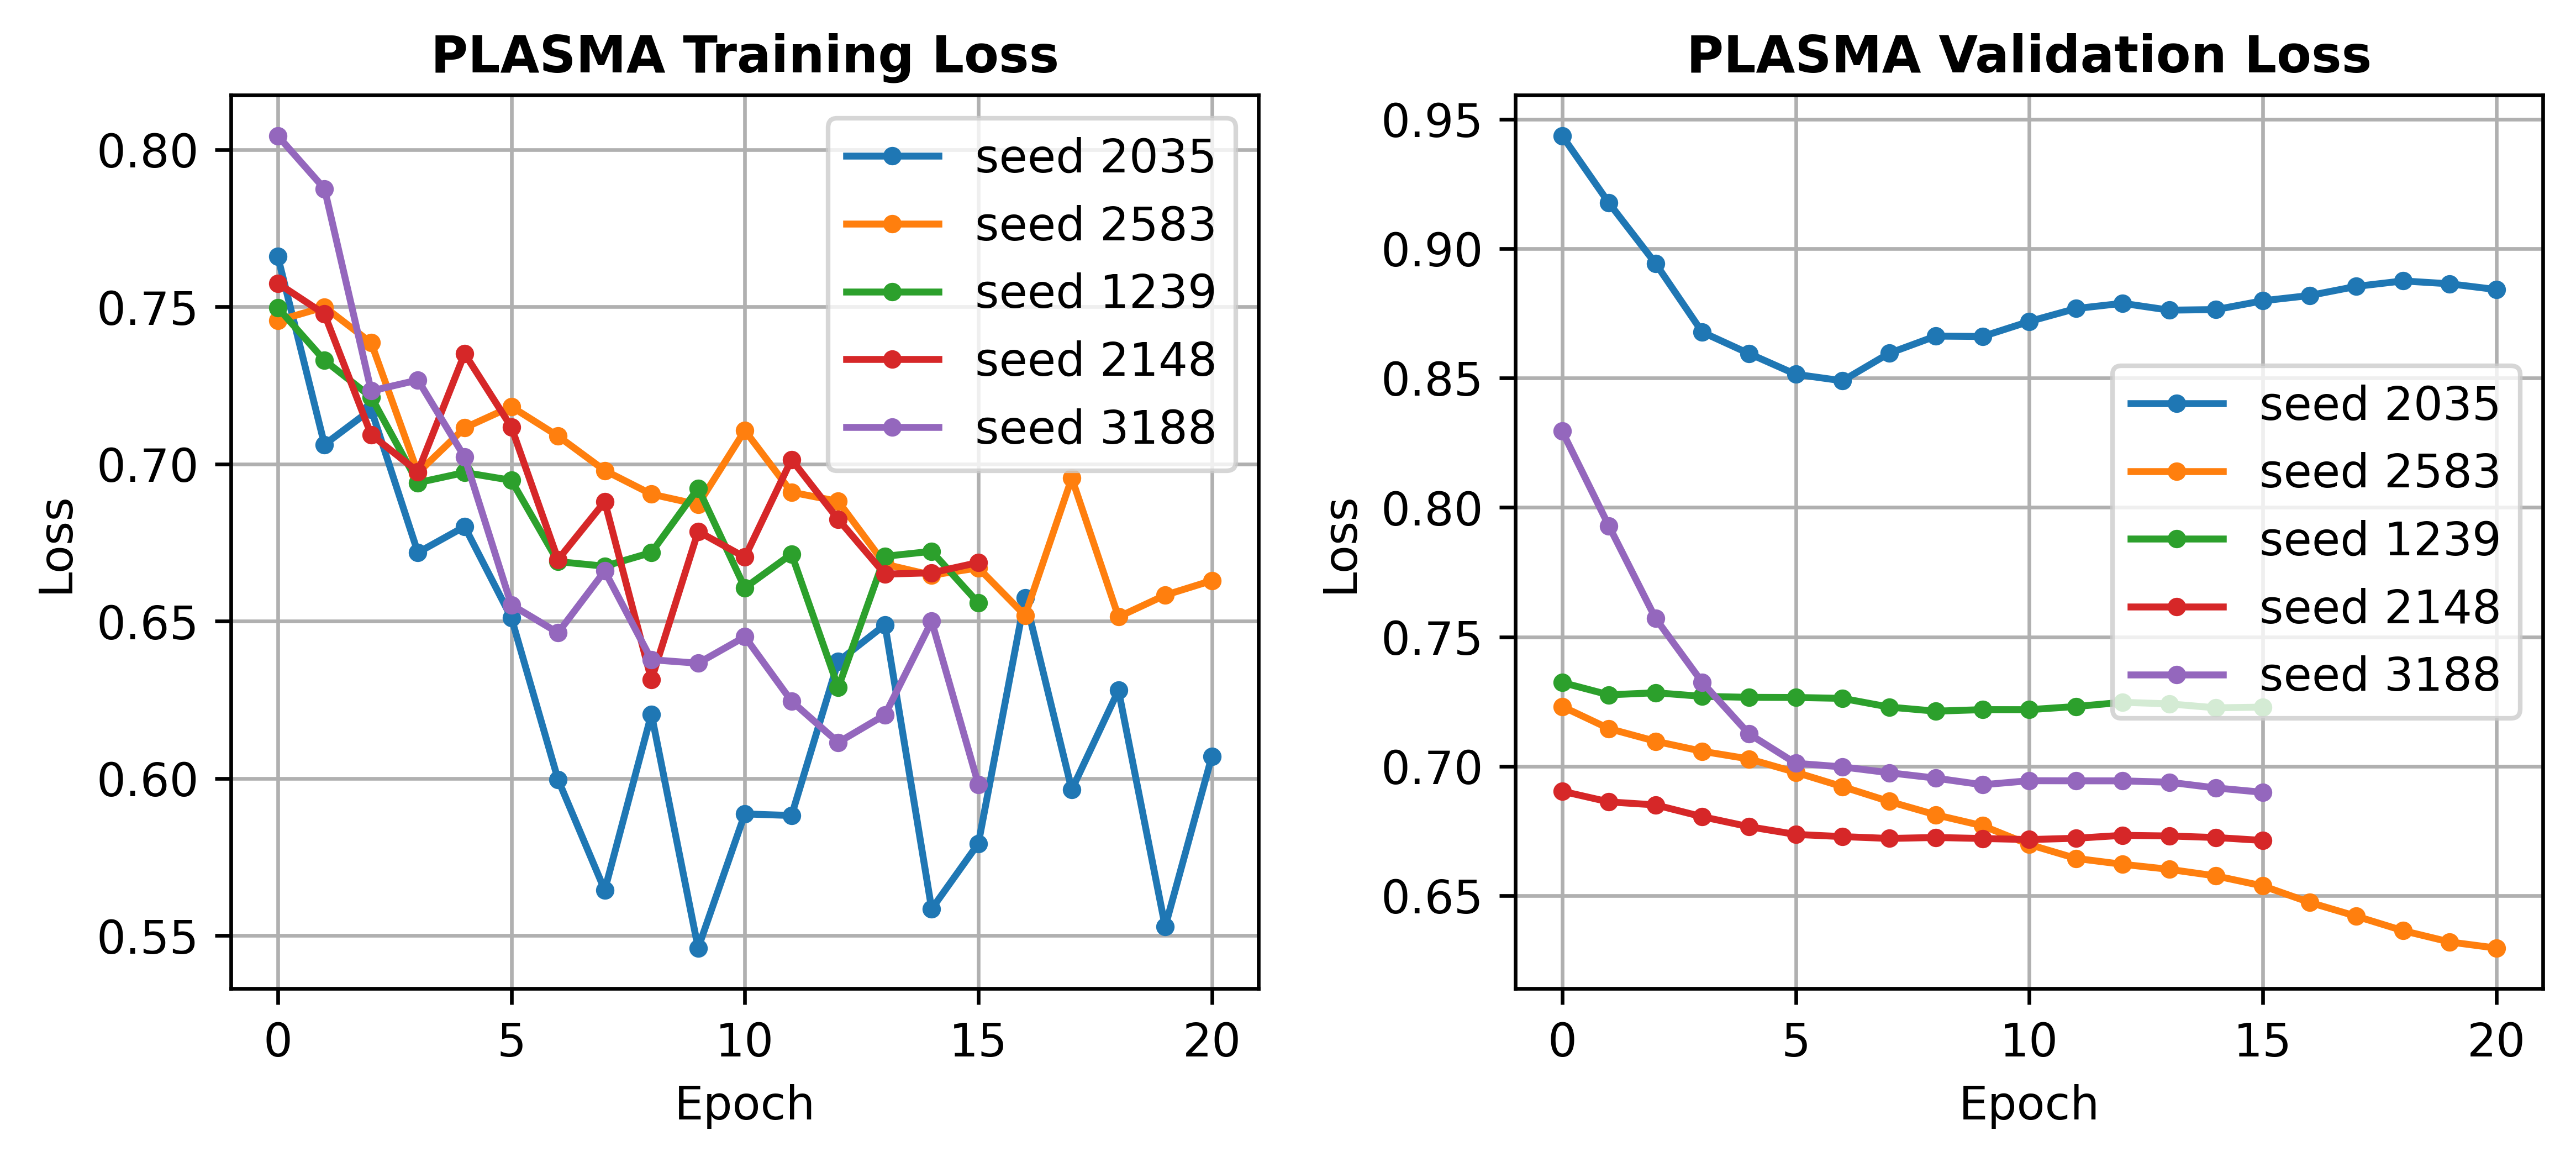

In [14]:
prms_final = update0(base0, best.params)
mte_final = run_cfg(prms_final, cols2, datadict1a, seeds5, cal_kind='platt', nboot=1000, boot_seed=42, return_all=True, strict_determinism=True, plot_metrics=True)
prms_final_obj = ModelParams(cols2, **prms_final)
plot_loss(mte_final)

#### **PLASMA SHAP**

In [15]:
import shap

class PLASMASHAP:
    def __init__(self, mte, params, device, seeds, n_perm=10):
        self.mte, self.params, self.device, self.seeds, self.n_perm = mte, params, device, seeds, n_perm
        self.feat_names = list(self.params.features[0]) + list(self.params.features[1]) + list(self.params.features[2])
    
    def _dataset_tensors(self, dataset):
        C = dataset.clin_data.to(self.device).float()
        E = dataset.expr_data.to(self.device).float()
        M = dataset.mut_data.to(self.device).float()
        y = dataset.labels.detach().cpu().numpy().astype(int)
        ids = dataset.ids
        X = np.concatenate([dataset.clin_data.detach().cpu().numpy(), dataset.expr_data.detach().cpu().numpy(), dataset.mut_data.detach().cpu().numpy(),], axis=1)
        return C, E, M, y, ids, X
    
    def _choose_background(self, C, E, M, n_bg=50, seed=0): # stratify by label to ensure balanced background
        y = self.mte['datasets']['train'].labels.numpy().astype(int) 
        rng = np.random.RandomState(seed)
        idx0 = np.where(y == 0)[0]
        idx1 = np.where(y == 1)[0]
        n_each = min(n_bg // 2, len(idx0), len(idx1))
        idx = np.concatenate([rng.choice(idx0, n_each, replace=False), rng.choice(idx1, n_each, replace=False)])
        return C[idx], E[idx], M[idx]

    def _get_stats(self):
        mod_imp, mod_means = {}, {}
        for i, modality in enumerate(['C', 'E', 'M']):
            abs_svals = self.phi_df[self.params.features[i]].abs()
            feature_means = abs_svals.mean() # mean importance per feature in modality X (feature-wise stats across patients)
            row_sums = abs_svals.sum(axis=1) # total importance of modality X per sample/patient (patient-wise stats across features)
            mod_means[modality] = feature_means
            mod_imp[modality] = {
                'f_mean': feature_means.mean(), # mean feature importance for modality X (global mean of all absolute SHAP values in modality X)
                'f_med': feature_means.median(), # median feature importance for modality X
                't_mean': row_sums.mean(), # average total importance of modality X
                't_med': row_sums.median() # median total importance of modality X
            }
        self.mod_means = pd.DataFrame(mod_means)
        self.mod_imp = pd.DataFrame.from_dict(mod_imp, orient='index')
        self.avgs = self.phi_df.abs().mean().rename('Average').sort_values(ascending=False).to_frame() # total averages
        self.avgs = pd.DataFrame(self.phi_df.abs().mean(), columns=['Average']).sort_values(by='Average', ascending=False) 
    
    def run(self, split='test_tcga', n_bg=50, bg_seed=0, model_idx=None, fn=''):
        model = self.mte['per_seed_models'][model_idx]
        tr_C, tr_E, tr_M, _, _, _   = self._dataset_tensors(self.mte['datasets']['train'])
        bg_C, bg_E, bg_M            = self._choose_background(tr_C, tr_E, tr_M, n_bg=n_bg, seed=bg_seed)
        te_C, te_E, te_M, y, ids, X = self._dataset_tensors(self.mte['datasets'][split])
        # PermutationExplainer requires flat numpy arrays — concatenate modalities
        n_clin = tr_C.shape[1]
        n_expr = tr_E.shape[1]
        # n_mut is remainder
        bg_flat = np.concatenate([bg_C.cpu().numpy(), bg_E.cpu().numpy(), bg_M.cpu().numpy()], axis=1) # (n_bg, F_total)
        te_flat = np.concatenate([te_C.cpu().numpy(), te_E.cpu().numpy(), te_M.cpu().numpy()], axis=1) # (N_test, F_total)
        model.eval()
        # splits flat numpy array back into modalities, runs model, returns logits as numpy (N,) — KernelExplainer needs numpy out
        def predict_fn(x_flat):
            x_tensor = torch.tensor(x_flat, dtype=torch.float32).to(self.device)
            xc = x_tensor[:, :n_clin]
            xe = x_tensor[:, n_clin:n_clin + n_expr]
            xm = x_tensor[:, n_clin + n_expr:]
            with torch.no_grad():
                logits, _, _, _ = model(x_c=xc, x_e=xe, x_m=xm)
            return logits.cpu().numpy()   # (N,)
        self.explainer = shap.PermutationExplainer(predict_fn, bg_flat)
        shap_vals = self.explainer.shap_values(te_flat, npermutations=self.n_perm)
        phi = np.asarray(shap_vals)
        mean_abs_phi = np.mean(np.abs(phi), axis=0) # (P,) global importance
        assert X.shape == phi.shape and len(self.feat_names) == X.shape[1], f'X {X.shape} != phi {phi.shape} or feat_names {len(self.feat_names)} != P {X.shape[1]}'
        phi_df = pd.DataFrame(phi, columns=self.feat_names, index=ids)
        self.phi, self.phi_df, self.X, self.y, self.ids, self.mean_abs_phi = phi, phi_df, X, y, ids, mean_abs_phi
        if fn != '':
            np.save(f'../results/{fn}.npy', self.phi)
            write_file('pd', f'{fn}.pkl', self.phi_df, '../results/')
        self._get_stats()
    
    def load(self, split='test_tcga', fn=''):
        te_C, te_E, te_M, self.y, self.ids, self.X = self._dataset_tensors(self.mte['datasets'][split])
        self.phi = np.load(f'../results/{fn}.npy')
        self.phi_df = load_data('pd', f'{fn}.pkl', '../results/')
        self.mean_abs_phi = np.mean(np.abs(self.phi), axis=0)
        self._get_stats()
    
    def print_modality_importance(self):
        modality_names = {'C': 'Clinical', 'E': 'Expression', 'M': 'Mutation'}
        for modality, row in self.mod_imp.iterrows():
            full_name = modality_names.get(modality, modality.capitalize())
            f_mean, f_med, t_mean, t_med = [f"{row[k]:.5f}" for k in ['f_mean', 'f_med', 't_mean', 't_med']]
            print(f"{full_name:<12} feature importance:    mean = {f_mean:<10} \tmedian = {f_med}")
            print(f"{'':<12} total importance:      mean = {t_mean:<10} \tmedian = {t_med}")
    
    def _add_shap_arrows(self, ax, y_frac=0.04, frac=0.60, base_frac=0.05, text_pad_frac=0.02, color="#5a5a5a", lw=2):
        # x in data coords, y in axes fraction
        trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
        xmin, xmax = ax.get_xlim()
        x0 = 0.0
        span_left  = max(1e-9, x0 - xmin)
        span_right = max(1e-9, xmax - x0)
        half = min(span_left, span_right)
        left_head  = x0 - frac * half
        right_head = x0 + frac * half
        base_offset = base_frac * half
        left_base  = x0 - base_offset
        right_base = x0 + base_offset
        y = y_frac
        pad = text_pad_frac * (xmax - xmin)
        ax.annotate("", xy=(right_head, y), xytext=(right_base, y), xycoords=trans, textcoords=trans, arrowprops=dict(arrowstyle='-|>', color=color, lw=lw),)
        ax.text(min(right_head + pad, xmax - pad), y, "early", transform=trans, va="center", ha="left", fontsize=10, fontweight="bold", color=color)
        ax.annotate("", xy=(left_head, y), xytext=(left_base, y), xycoords=trans, textcoords=trans, arrowprops=dict(arrowstyle='-|>', color=color, lw=lw),)
        ax.text(max(left_head - pad, xmin + pad), y, "late", transform=trans, va="center", ha="right", fontsize=10, fontweight="bold", color=color)

    def plot_results(self, max_display=20, dpi=1000, w=15, h=10, p_lower_margin_increase=0, arrow_y=.04, frac=0.60, base_frac=0.02, bottom_pad=0.2, **kwargs):
        def clean_feature(f):
            if 'ORF' in f: f = f.replace('ORF', 'orf')
            if f.endswith('_mut'): return rf"$\it{{{f[:-4]}}}$ mutations"
            if f.endswith('_expr'): return rf"$\it{{{f[:-5]}}}$ expression"
            if f.startswith('stage'): return f"Stage {f.replace('stage_','').upper()}"
            return f.replace('_', ' ').capitalize()
        clean_cols = [clean_feature(f) for f in self.feat_names]
        fig = plt.figure(figsize=(w, h), dpi=dpi)
        shap.summary_plot(self.phi, self.X, feature_names=clean_cols, show=False, max_display=max_display, plot_size=(w, h), **kwargs)
        fig.set_dpi(dpi)
        plt.title(f'TCGA: PLASMA SHAP Feature Importance', pad=8, color='black', fontsize='large', fontweight='bold')
        plt.xlabel(plt.gca().get_xlabel(), labelpad=5, color='black', fontsize='large')
        plt.xticks(color='black')
        ax = plt.gca()
        ax.tick_params(axis='y', pad=5, reset=True, color='black', labelsize=11, right=False)
        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymin - bottom_pad, ymax)
        ax.grid(True, axis='y', color='gray', linestyle=':', linewidth=0.5, alpha=0.9)
        if p_lower_margin_increase:
            plt.subplots_adjust(bottom=p_lower_margin_increase)
        for spine in ax.spines.values():
            spine.set_visible(True); spine.set_color('black')
        self._add_shap_arrows(ax, y_frac=arrow_y, frac=frac, base_frac=base_frac, text_pad_frac=0.005, color="#1A1919")
        plt.show()

Clinical     feature importance:    mean = 0.14704    	median = 0.12772
             total importance:      mean = 1.02926    	median = 1.03704
Expression   feature importance:    mean = 0.03090    	median = 0.02436
             total importance:      mean = 1.54501    	median = 1.45581
Mutation     feature importance:    mean = 0.03389    	median = 0.02477
             total importance:      mean = 1.69452    	median = 1.69902


/tmp/ipykernel_1877347/3296188122.py:121: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(self.phi, self.X, feature_names=clean_cols, show=False, max_display=max_display, plot_size=(w, h), **kwargs)


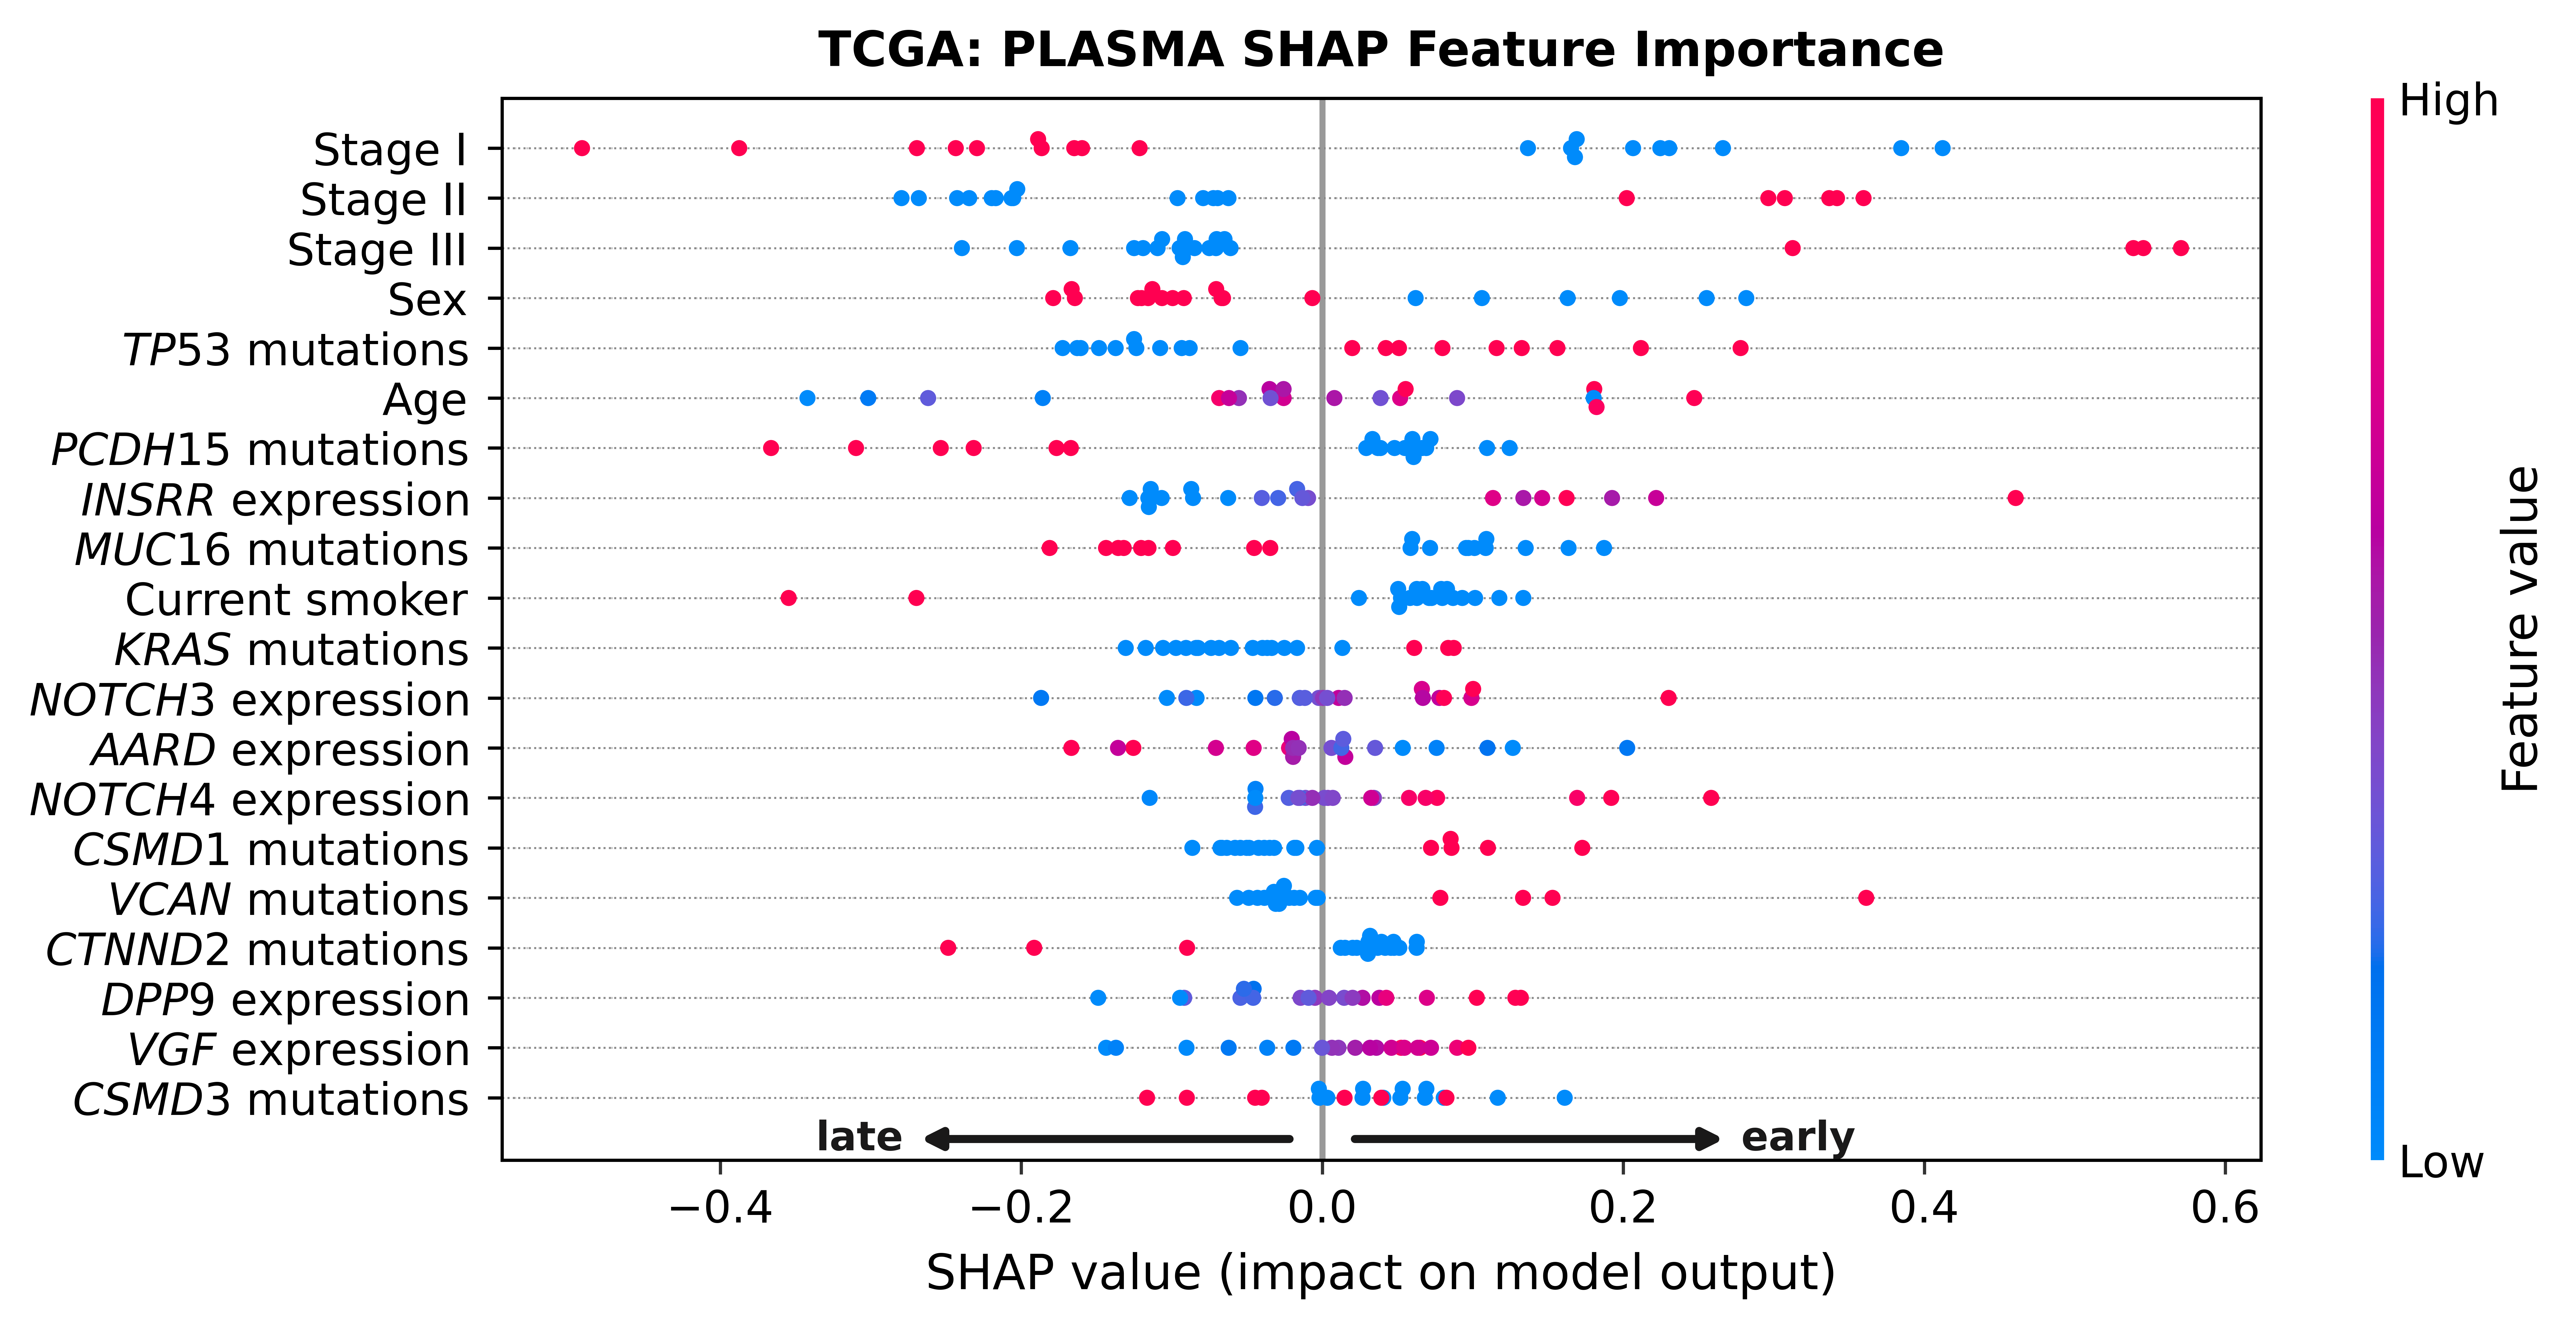

In [16]:
pshap = PLASMASHAP(mte_final, prms_final_obj, device, seeds5)
# pshap.run(split='test_tcga', n_bg=50, bg_seed=9999, model_idx=0, fn='shap_may5')
pshap.load(split='test_tcga', fn='shap_may5')
pshap.print_modality_importance()
pshap.plot_results(max_display=20, w=10, h=4.5, arrow_y=.02, frac=.5, base_frac=.03, bottom_pad=0.25)

#### **ABLATION 1: NO-ATTENTION / SIMPLE CONCAT**

In [17]:
base_concat = copy.deepcopy(base0)
base_concat['att']['use'] = False

stg = f'sqlite:///{STUDIES_DIR}/0_concat.db'
# result_concat = tune_hyperparameters(datadict1a, cols2, device, storage=stg, n_trials=80, k=3, n_seeds_per_fold=5, n_startup_trials=30, inner_val_frac=0.15, seed=9999, base_overrides=base_concat, search_space=search0, verbose=True, study_name='0_concat')
study = optuna.load_study(study_name='0_concat', storage=stg)
result_concat = {'study': study, 'best_value': float(study.best_value), 'best_params': dict(study.best_params)}
best, meta = best_trial_with_tiebreak(result_concat['study'], secondary='fold_mean_auprc', return_meta=True)
print(f"Optuna pick: val={result_concat['best_value']:.5f} params={result_concat['best_params']}")
print(f"Tie-broken:  val={best.value:.5f} params={best.params}\nTie meta: {meta}")

Optuna pick: val=0.54281 params={'clin_lr': 0.0003, 'expr_lr': 0.0005, 'mut_lr': 0.0001, 'fus_lr': 0.0005, 'grace': 12, 'factor': 0.6, 'cool': 1}
Tie-broken:  val=0.54281 params={'clin_lr': 0.0003, 'expr_lr': 0.0005, 'mut_lr': 0.0001, 'fus_lr': 0.0005, 'grace': 12, 'factor': 0.6, 'cool': 1}
Tie meta: {'top_value': 0.5428131732840874, 'tol': 1e-06, 'n_tied': 22, 'tied_numbers': [38, 41, 42, 43, 44, 45, 48, 49, 51, 52, 53, 54, 61, 62, 63, 64, 65, 71, 72, 73, 74, 75], 'secondary': 'fold_mean_auprc', 'chosen_number': 38}


In [18]:
prms_concat = update0(base_concat, best.params)
mte_concat = run_cfg(prms_concat, cols2, datadict1a, seeds5, cal_kind='platt', nboot=1000, boot_seed=42, return_all=True, strict_determinism=True, plot_metrics=True)

,auc,auprc,avg_prec,bal_acc,prec,rec,spec,f1,tn,fp,fn,tp
Val TCGA,59.00,70.22,71.35,70.00,100.00,40.00,100.00,57.14,10,0,6,4
Test TCGA,65.00,62.42,65.16,60.00,66.67,40.00,80.00,50.00,8,2,6,4
Test TRCR,53.33,56.06,57.26,46.39,46.67,19.44,73.33,27.45,22,8,29,7


#### **ABLATION 2: MODALITIES**

In [19]:
# for single modality cases, fus_opt and fus are still used as they include the prediction head (which single modality uses now)
def search_ablation(version):
    if version not in ('C', 'E', 'M', 'CE', 'CM', 'EM'): raise ValueError(f"version must be in [C, E, M, CE, CM, EM] got {version!r}")
    keys = [{'C': 'clin', 'E': 'expr', 'M': 'mut'}[m] for m in list(version)]
    def fn(trial):
        return {
            **{f'{key}_opt': dict(lr=trial.suggest_categorical(f'{key}_lr', [.0003, .0001, .0005])) for key in keys}, # opts for each modality
            'fus_opt': dict(lr=trial.suggest_categorical('fus_lr', [.0003, .0001, .0005])),
            'es': dict(grace_epochs=trial.suggest_categorical('grace', [8, 10, 12])),
            'sched': dict(factor=trial.suggest_categorical('factor', [.3, .5, .6]), cooldown=trial.suggest_categorical('cool', [0, 1, 2, 3]))
        }
    return fn

def update_ablation(base, bp, version):
    new = copy.deepcopy(base)
    for m in list(version):
        key = {'C': 'clin', 'E': 'expr', 'M': 'mut'}[m]
        new[f'{key}_opt']['lr'] = bp[f'{key}_lr']
    new['fus_opt']['lr'] = bp['fus_lr']
    new['es']['grace_epochs'] = bp['grace']
    new['sched'].update({'factor': bp['factor'], 'cooldown': bp['cool']})
    return new

def tuned_ablation(action, base, version, study_name, seed=9999, secondary='first'): # 'first' is the Optuna default, same as not calculating best/leaving as is
    b = copy.deepcopy(base)
    b['version'] = version
    is_single = len(version) == 1
    stg = f'sqlite:///{STUDIES_DIR}/{study_name}.db'
    if action == 'run': 
        n_t, n_start = (40, 15) if is_single else (60, 20)
        result = tune_hyperparameters(datadict1a, cols2, device, storage=stg, n_trials=n_t, k=3, n_seeds_per_fold=5, n_startup_trials=n_start, seed=seed, base_overrides=b, search_space=search_ablation(version), study_name=study_name) # inner val defaults to .15 
    else:
        study = optuna.load_study(study_name=study_name, storage=stg)
        result = {'study': study, 'best_value': float(study.best_value), 'best_params': dict(study.best_params)}
    best, meta = best_trial_with_tiebreak(result['study'], secondary=secondary, return_meta=True)
    print(f"Optuna pick: val={result['best_value']:.5f} params={result['best_params']}")
    print(f"Tie-broken:  val={best.value:.5f} params={best.params}\nTie meta: {meta}")
    prms_new = update_ablation(b, best.params, version)
    mte_new = run_cfg(prms_new, cols2, datadict1a, seeds5, cal_kind='platt', nboot=1000, boot_seed=42, return_all=True, strict_determinism=True, plot_metrics=True)
    return result, prms_new, mte_new 

In [20]:
result_C, prms_C, mte_C = tuned_ablation('load', base0, 'C', '0_C', seed=9999, secondary='fold_std')

Optuna pick: val=0.53230 params={'clin_lr': 0.0005, 'fus_lr': 0.0005, 'grace': 10, 'factor': 0.6, 'cool': 3}
Tie-broken:  val=0.53230 params={'clin_lr': 0.0005, 'fus_lr': 0.0005, 'grace': 10, 'factor': 0.6, 'cool': 3}
Tie meta: {'top_value': 0.53229711706166, 'tol': 1e-06, 'n_tied': 9, 'tied_numbers': [25, 26, 27, 31, 32, 33, 34, 36, 39], 'secondary': 'fold_std', 'chosen_number': 25}


,auc,auprc,avg_prec,bal_acc,prec,rec,spec,f1,tn,fp,fn,tp
Val TCGA,70.00,74.17,75.49,70.00,64.29,90.00,50.00,75.00,5,5,1,9
Test TCGA,82.00,84.21,85.01,75.00,72.73,80.00,70.00,76.19,7,3,2,8
Test TRCR,69.72,68.25,70.25,66.94,67.44,80.56,53.33,73.42,16,14,7,29


In [21]:
result_E, prms_E, mte_E = tuned_ablation('load', base0, 'E', '0_E', seed=9999, secondary='fold_std')

Optuna pick: val=0.66053 params={'expr_lr': 0.0005, 'fus_lr': 0.0001, 'grace': 12, 'factor': 0.6, 'cool': 3}
Tie-broken:  val=0.66053 params={'expr_lr': 0.0005, 'fus_lr': 0.0001, 'grace': 12, 'factor': 0.6, 'cool': 3}
Tie meta: {'top_value': 0.6605314455729969, 'tol': 1e-06, 'n_tied': 1, 'tied_numbers': [37], 'secondary': 'fold_std', 'chosen_number': 37}


,auc,auprc,avg_prec,bal_acc,prec,rec,spec,f1,tn,fp,fn,tp
Val TCGA,67.00,66.38,68.99,70.00,75.00,60.00,80.00,66.67,8,2,4,6
Test TCGA,63.00,63.33,66.02,60.00,62.50,50.00,70.00,55.56,7,3,5,5
Test TRCR,55.83,54.89,56.79,54.72,59.38,52.78,56.67,55.88,17,13,17,19


In [22]:
result_M, prms_M, mte_M = tuned_ablation('load', base0, 'M', '0_M', seed=9999, secondary='fold_std')

Optuna pick: val=0.50373 params={'mut_lr': 0.0001, 'fus_lr': 0.0003, 'grace': 12, 'factor': 0.5, 'cool': 0}
Tie-broken:  val=0.50373 params={'mut_lr': 0.0001, 'fus_lr': 0.0003, 'grace': 12, 'factor': 0.5, 'cool': 0}
Tie meta: {'top_value': 0.5037344824048425, 'tol': 1e-06, 'n_tied': 16, 'tied_numbers': [7, 14, 16, 17, 20, 21, 22, 23, 24, 26, 27, 31, 32, 33, 34, 36], 'secondary': 'fold_std', 'chosen_number': 7}


,auc,auprc,avg_prec,bal_acc,prec,rec,spec,f1,tn,fp,fn,tp
Val TCGA,79.00,81.02,82.11,80.00,80.00,80.00,80.00,80.00,8,2,2,8
Test TCGA,49.00,50.09,55.31,45.00,45.45,50.00,40.00,47.62,4,6,5,5
Test TRCR,46.11,57.31,58.06,45.56,50.00,44.44,46.67,47.06,14,16,20,16


In [23]:
result_CE, prms_CE, mte_CE = tuned_ablation('load', base0, 'CE', '0_CE', seed=9999, secondary='fold_std')

Optuna pick: val=0.54163 params={'clin_lr': 0.0005, 'expr_lr': 0.0005, 'fus_lr': 0.0003, 'grace': 12, 'factor': 0.6, 'cool': 3}
Tie-broken:  val=0.54163 params={'clin_lr': 0.0005, 'expr_lr': 0.0005, 'fus_lr': 0.0003, 'grace': 12, 'factor': 0.6, 'cool': 3}
Tie meta: {'top_value': 0.5416333230737663, 'tol': 1e-06, 'n_tied': 22, 'tied_numbers': [14, 15, 16, 17, 21, 22, 23, 24, 25, 26, 31, 32, 33, 36, 41, 42, 43, 51, 52, 53, 54, 59], 'secondary': 'fold_std', 'chosen_number': 14}


,auc,auprc,avg_prec,bal_acc,prec,rec,spec,f1,tn,fp,fn,tp
Val TCGA,51.00,63.38,64.88,65.00,100.00,30.00,100.00,46.15,10,0,7,3
Test TCGA,68.00,72.91,74.26,60.00,100.00,20.00,100.00,33.33,10,0,8,2
Test TRCR,70.37,75.86,76.29,54.17,100.00,8.33,100.00,15.38,30,0,33,3


In [24]:
result_CM, prms_CM, mte_CM = tuned_ablation('load', base0, 'CM', '0_CM', seed=9999, secondary='fold_std')

Optuna pick: val=0.57232 params={'clin_lr': 0.0001, 'mut_lr': 0.0001, 'fus_lr': 0.0005, 'grace': 10, 'factor': 0.6, 'cool': 2}
Tie-broken:  val=0.57232 params={'clin_lr': 0.0001, 'mut_lr': 0.0001, 'fus_lr': 0.0005, 'grace': 10, 'factor': 0.6, 'cool': 2}
Tie meta: {'top_value': 0.5723196881091618, 'tol': 1e-06, 'n_tied': 7, 'tied_numbers': [39, 41, 42, 43, 47, 56, 58], 'secondary': 'fold_std', 'chosen_number': 39}


,auc,auprc,avg_prec,bal_acc,prec,rec,spec,f1,tn,fp,fn,tp
Val TCGA,54.00,59.44,62.21,65.00,71.43,50.00,80.00,58.82,8,2,5,5
Test TCGA,36.00,49.67,52.42,55.00,66.67,20.00,90.00,30.77,9,1,8,2
Test TRCR,71.48,78.13,78.51,69.72,82.61,52.78,86.67,64.41,26,4,17,19


In [25]:
result_EM, prms_EM, mte_EM = tuned_ablation('load', base0, 'EM', '0_EM', seed=9999, secondary='fold_std')

Optuna pick: val=0.50129 params={'expr_lr': 0.0005, 'mut_lr': 0.0001, 'fus_lr': 0.0005, 'grace': 12, 'factor': 0.6, 'cool': 1}
Tie-broken:  val=0.50129 params={'expr_lr': 0.0005, 'mut_lr': 0.0001, 'fus_lr': 0.0005, 'grace': 12, 'factor': 0.6, 'cool': 1}
Tie meta: {'top_value': 0.5012927054478301, 'tol': 1e-06, 'n_tied': 19, 'tied_numbers': [18, 21, 22, 23, 24, 25, 27, 31, 32, 33, 34, 36, 41, 42, 43, 51, 52, 53, 54], 'secondary': 'fold_std', 'chosen_number': 18}


,auc,auprc,avg_prec,bal_acc,prec,rec,spec,f1,tn,fp,fn,tp
Val TCGA,69.00,69.40,71.25,70.00,64.29,90.00,50.00,75.00,5,5,1,9
Test TCGA,23.00,35.14,38.85,30.00,25.00,20.00,40.00,22.22,4,6,8,2
Test TRCR,63.61,61.03,62.51,56.67,62.07,50.00,63.33,55.38,19,11,18,18


#### **BASELINES**

In [26]:
from train_util import compute_metrics, Calibrator, choose_threshold, bootstrap_metrics
import baseline_tune; importlib.reload(baseline_tune)
from baseline_tune import tune_baseline, tune_all_baselines, summarize_tuning, _make_lr, _make_rf, _make_mlp, _make_svm, _make_knn

_STOCHASTIC = {'LR': False, 'RF': True, 'MLP': True, 'SVM': False, 'KNN': False} # whether the model is genuinely stochastic
_MODEL_FACTORIES = {'LR': _make_lr, 'RF': _make_rf, 'MLP': _make_mlp, 'SVM': _make_svm, 'KNN': _make_knn}

def _make_factory(tuned):
    def fn(seed):
        return {k: _MODEL_FACTORIES[k](seed=seed, **tuned[k]['best_hp']) for k in tuned.keys()}
    return fn

In [27]:
tuned = tune_all_baselines(datadict1a, cols2, names=('LR', 'RF', 'MLP', 'SVM', 'KNN'), k=3, n_seeds_per_fold=5, seed=9999, tiebreak='fold_std', storage_dir=STUDIES_DIR)

[I 2026-05-11 21:37:00,702] Using an existing study with name 'LR' instead of creating a new one.



=== Tuning LR (grid: 30 combos) ===
[LR] deterministic model — using 1 seed per fold
[LR] all 30 grid combos already complete; loaded from storage
[LR] best CV AUC: 0.7820 (6 tied; tiebreak=fold_std -> trial #0)
[LR] best HPs:    {'C': 0.01, 'l1_ratio': 0, 'tol': 0.01}

=== Tuning RF (grid: 72 combos) ===


[I 2026-05-11 21:37:01,012] Using an existing study with name 'RF' instead of creating a new one.
[I 2026-05-11 21:37:01,355] Using an existing study with name 'MLP' instead of creating a new one.


[RF] all 72 grid combos already complete; loaded from storage
[RF] best CV AUC: 0.7625 (trial #52)
[RF] best HPs:    {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 100, 'max_features': 'log2'}

=== Tuning MLP (grid: 72 combos) ===


[I 2026-05-11 21:37:01,672] Using an existing study with name 'SVM' instead of creating a new one.


[MLP] all 72 grid combos already complete; loaded from storage
[MLP] best CV AUC: 0.7723 (trial #31)
[MLP] best HPs:    {'alpha': 0.001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.005}

=== Tuning SVM (grid: 24 combos) ===
[SVM] deterministic model — using 1 seed per fold


[I 2026-05-11 21:37:01,963] Using an existing study with name 'KNN' instead of creating a new one.


[SVM] all 24 grid combos already complete; loaded from storage
[SVM] best CV AUC: 0.7541 (2 tied; tiebreak=fold_std -> trial #0)
[SVM] best HPs:    {'C': 1, 'gamma': 'auto', 'shrinking': True}

=== Tuning KNN (grid: 36 combos) ===
[KNN] deterministic model — using 1 seed per fold
[KNN] all 36 grid combos already complete; loaded from storage
[KNN] best CV AUC: 0.7960 (3 tied; tiebreak=fold_std -> trial #1)
[KNN] best HPs:    {'n_neighbors': 50, 'weights': 'distance', 'p': 2, 'leaf_size': 50}


In [28]:
summarize_tuning(tuned)

LR:	best_auc = 0.782 (30 trials, 6 tied)	best HP = {'C': 0.01, 'l1_ratio': 0, 'tol': 0.01}
RF:	best_auc = 0.7625 (72 trials, 0 tied)	best HP = {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 100, 'max_features': 'log2'}
MLP:	best_auc = 0.7723 (72 trials, 0 tied)	best HP = {'alpha': 0.001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.005}
SVM:	best_auc = 0.7541 (24 trials, 2 tied)	best HP = {'C': 1, 'gamma': 'auto', 'shrinking': True}
KNN:	best_auc = 0.796 (36 trials, 3 tied)	best HP = {'n_neighbors': 50, 'weights': 'distance', 'p': 2, 'leaf_size': 50}


In [29]:
def convert_numpy(obj):
    if isinstance(obj, defaultdict) or isinstance(obj, dict): return {k: convert_numpy(v) for k, v in obj.items()}
    if isinstance(obj, list): return [convert_numpy(i) for i in obj]
    if isinstance(obj, np.integer): return int(obj)
    if isinstance(obj, np.floating): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    return obj

def _dataset_to_numpy(dataset): # extract flat concatenated (C+E+M) numpy arrays from a MultiModalDataset
    X = np.concatenate([dataset.clin_data.numpy(), dataset.expr_data.numpy(), dataset.mut_data.numpy()], axis=1).astype(float)
    y = dataset.labels.numpy().astype(int)
    return X, y, dataset.ids

def format_baseline_comparison(baseline_results, show_n_seeds=True):
    metrics_to_show = ['auc', 'auprc', 'bal_acc', 'avg_prec', 'rec', 'spec', 'f1', 'tn', 'fp', 'fn', 'tp']
    int_cols = {'tn', 'fp', 'fn', 'tp'}
    def build_row(metrics_dict, n_seeds=None):
        row = {m: (metrics_dict[m] if m in int_cols else round(metrics_dict[m] * 100, 2)) for m in metrics_to_show}
        if show_n_seeds:
            row['n_seeds'] = n_seeds if n_seeds is not None else '—'
        return row
    tables = {}
    for split in ['tcga_test', 'tracerx']:
        rows = {}
        for name, res in baseline_results.items():
            rows[name] = build_row(res['results'][split]['metrics'], n_seeds=res.get('n_seeds_used'))
        tables[split] = pd.DataFrame(rows).T.sort_values('auc', ascending=False)
    return tables

def get_logits(clf, X, eps=1e-7):
    # output is the model's raw decision_function when available, otherwise a logit derived from predict_proba; the score is suitable for AUC computation and as input to calibrator
    classes = list(clf.classes_)
    if 1 not in classes: raise ValueError(f"Positive class '1' not in clf.classes_={classes}")
    idx = classes.index(1)
    if hasattr(clf, 'decision_function'):
        z = np.asarray(clf.decision_function(X)).ravel()
        # decision_function points toward clf.classes_[1]; if positive class is at index 0 instead, flip the sign
        if idx == 0: z = -z 
        return z
    if hasattr(clf, 'predict_proba'):
        p = clf.predict_proba(X)[:, idx]
    elif hasattr(clf, 'predict_log_proba'):
        p = np.exp(clf.predict_log_proba(X)[:, idx])
    else: raise ValueError('Model exposes neither decision_function nor predict_proba.')
    p = np.clip(p, eps, 1 - eps)
    return np.log(p/(1 - p))

def run_ml_baselines(datasets, params, seeds, calibrator_kind='platt', n_boot=1000, boot_seed=0, baselines_factory=None, plot_metrics=False, verbose=True):
    # train baselines, ensemble across seeds (where meaningful), then calibrate and threshold using the same protocol as PLASMA
    X_tr, y_tr, _ = _dataset_to_numpy(datasets['train'])
    X_va, y_va, _ = _dataset_to_numpy(datasets['val'])
    X_te, y_te, _ = _dataset_to_numpy(datasets['test_tcga'])
    X_trx, y_trx, _ = _dataset_to_numpy(datasets['test_trcr'])
    if baselines_factory is None:
        raise ValueError("Baseline factory not provided")
    baseline_names = list(baselines_factory(seeds[0]).keys())
    per_seed_scores = {name: {split: {'scores': [], 'targets': []} for split in ['tcga_val', 'tcga_test', 'tracerx']} for name in baseline_names}
    per_seed_models = {name: [] for name in baseline_names}
    for seed_idx, seed in enumerate(seeds):
        baselines = baselines_factory(seed)
        for name, clf in baselines.items():
            # deterministic models are only fit on the first seed; scores are identical across seeds and downstream averaging would just reproduce them
            if not _STOCHASTIC.get(name, True) and seed_idx > 0: continue
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                clf.fit(X_tr, y_tr)
            per_seed_models[name].append(clf)
            for split, X, y in [('tcga_val', X_va, y_va), ('tcga_test', X_te, y_te), ('tracerx', X_trx, y_trx)]:
                per_seed_scores[name][split]['scores'].append(get_logits(clf, X))
                per_seed_scores[name][split]['targets'].append(y)
    # aggregate, calibrate, threshold
    all_results, n_seeds_used = {}, {}
    for name in baseline_names:
        n_seeds_used[name] = len(per_seed_scores[name]['tcga_val']['scores'])
        ens = {}
        for split in ['tcga_val', 'tcga_test', 'tracerx']:
            ens[split] = {'scores': np.stack(per_seed_scores[name][split]['scores'], axis=0).mean(axis=0), 'targets': per_seed_scores[name][split]['targets'][0].astype(int)}
        cal = Calibrator(kind=calibrator_kind).fit(ens['tcga_val']['scores'], ens['tcga_val']['targets'])
        for split in ['tcga_val', 'tcga_test', 'tracerx']:
            ens[split]['probs_cal'] = cal.transform(ens[split]['scores'])
        thr, thr_meta = choose_threshold(y_true=ens['tcga_val']['targets'], y_prob=ens['tcga_val']['probs_cal'], target=params.threshold_target)
        results = {}
        for split in ['tcga_val', 'tcga_test', 'tracerx']:
            y = ens[split]['targets']
            p = ens[split]['probs_cal']
            point = compute_metrics(y, p, threshold=thr, plot_metrics=plot_metrics)
            ci = (bootstrap_metrics(y, p, threshold=thr, n_boot=n_boot, seed=boot_seed) if n_boot > 0 else None)
            results[split] = {'metrics': point, 'bootstrap_ci': ci, 'prevalence': float(np.mean(y))}
        all_results[name] = {'results': results, 'threshold': thr, 'models': per_seed_models[name], 'ensemble': ens, 'calibrator': cal, 'n_seeds_used': n_seeds_used[name]}
        if verbose:
            n = n_seeds_used[name]
            tag = f"({n} seed{'s' if n != 1 else ''})"
            val_auc = roc_auc_score(ens['tcga_val']['targets'], ens['tcga_val']['scores'])
            print(f"{name:6s} {tag:11s}  val AUC={val_auc:.3f}  TCGA test AUC={results['tcga_test']['metrics']['auc']:.3f}  TracerX AUC={results['tracerx']['metrics']['auc']:.3f}")
    return all_results

In [30]:
f = _make_factory(tuned)
baseline_results = run_ml_baselines(datasets=mte_final['datasets'], params=prms_final_obj, seeds=seeds5, calibrator_kind='platt', n_boot=1000, boot_seed=42, baselines_factory=f, plot_metrics=True)
baseline_results['PLASMA'] = {'results': mte_final['results'], 'n_seeds_used': 5}
ml_tables = format_baseline_comparison(baseline_results, show_n_seeds=False)
display(ml_tables['tcga_test']); display(ml_tables['tracerx'])

LR     (1 seed)     val AUC=0.690  TCGA test AUC=0.670  TracerX AUC=0.539
RF     (5 seeds)    val AUC=0.700  TCGA test AUC=0.620  TracerX AUC=0.588
MLP    (5 seeds)    val AUC=0.690  TCGA test AUC=0.660  TracerX AUC=0.610
SVM    (1 seed)     val AUC=0.750  TCGA test AUC=0.650  TracerX AUC=0.614
KNN    (1 seed)     val AUC=0.600  TCGA test AUC=0.740  TracerX AUC=0.526


,auc,auprc,bal_acc,avg_prec,rec,spec,f1,tn,fp,fn,tp
PLASMA,85.0,87.94,80.0,88.46,80.0,80.0,80.00,8.0,2.0,2.0,8.0
KNN,74.0,75.26,65.0,76.62,70.0,60.0,66.67,6.0,4.0,3.0,7.0
LR,67.0,71.67,60.0,73.32,80.0,40.0,66.67,4.0,6.0,2.0,8.0
MLP,66.0,76.63,50.0,77.55,60.0,40.0,54.55,4.0,6.0,4.0,6.0
SVM,65.0,73.56,55.0,74.66,80.0,30.0,64.00,3.0,7.0,2.0,8.0
RF,62.0,66.19,65.0,68.08,80.0,50.0,69.57,5.0,5.0,2.0,8.0


,auc,auprc,bal_acc,avg_prec,rec,spec,f1,tn,fp,fn,tp
PLASMA,76.48,79.55,71.11,79.95,55.56,86.67,66.67,26.0,4.0,16.0,20.0
SVM,61.39,61.63,62.50,62.77,75.00,50.00,69.23,15.0,15.0,9.0,27.0
MLP,61.02,62.03,57.22,63.00,61.11,53.33,61.11,16.0,14.0,14.0,22.0
RF,58.80,55.60,62.22,57.03,77.78,46.67,70.00,14.0,16.0,8.0,28.0
LR,53.89,52.28,59.72,53.71,69.44,50.00,65.79,15.0,15.0,11.0,25.0
KNN,52.59,52.40,55.56,54.27,61.11,50.00,60.27,15.0,15.0,14.0,22.0


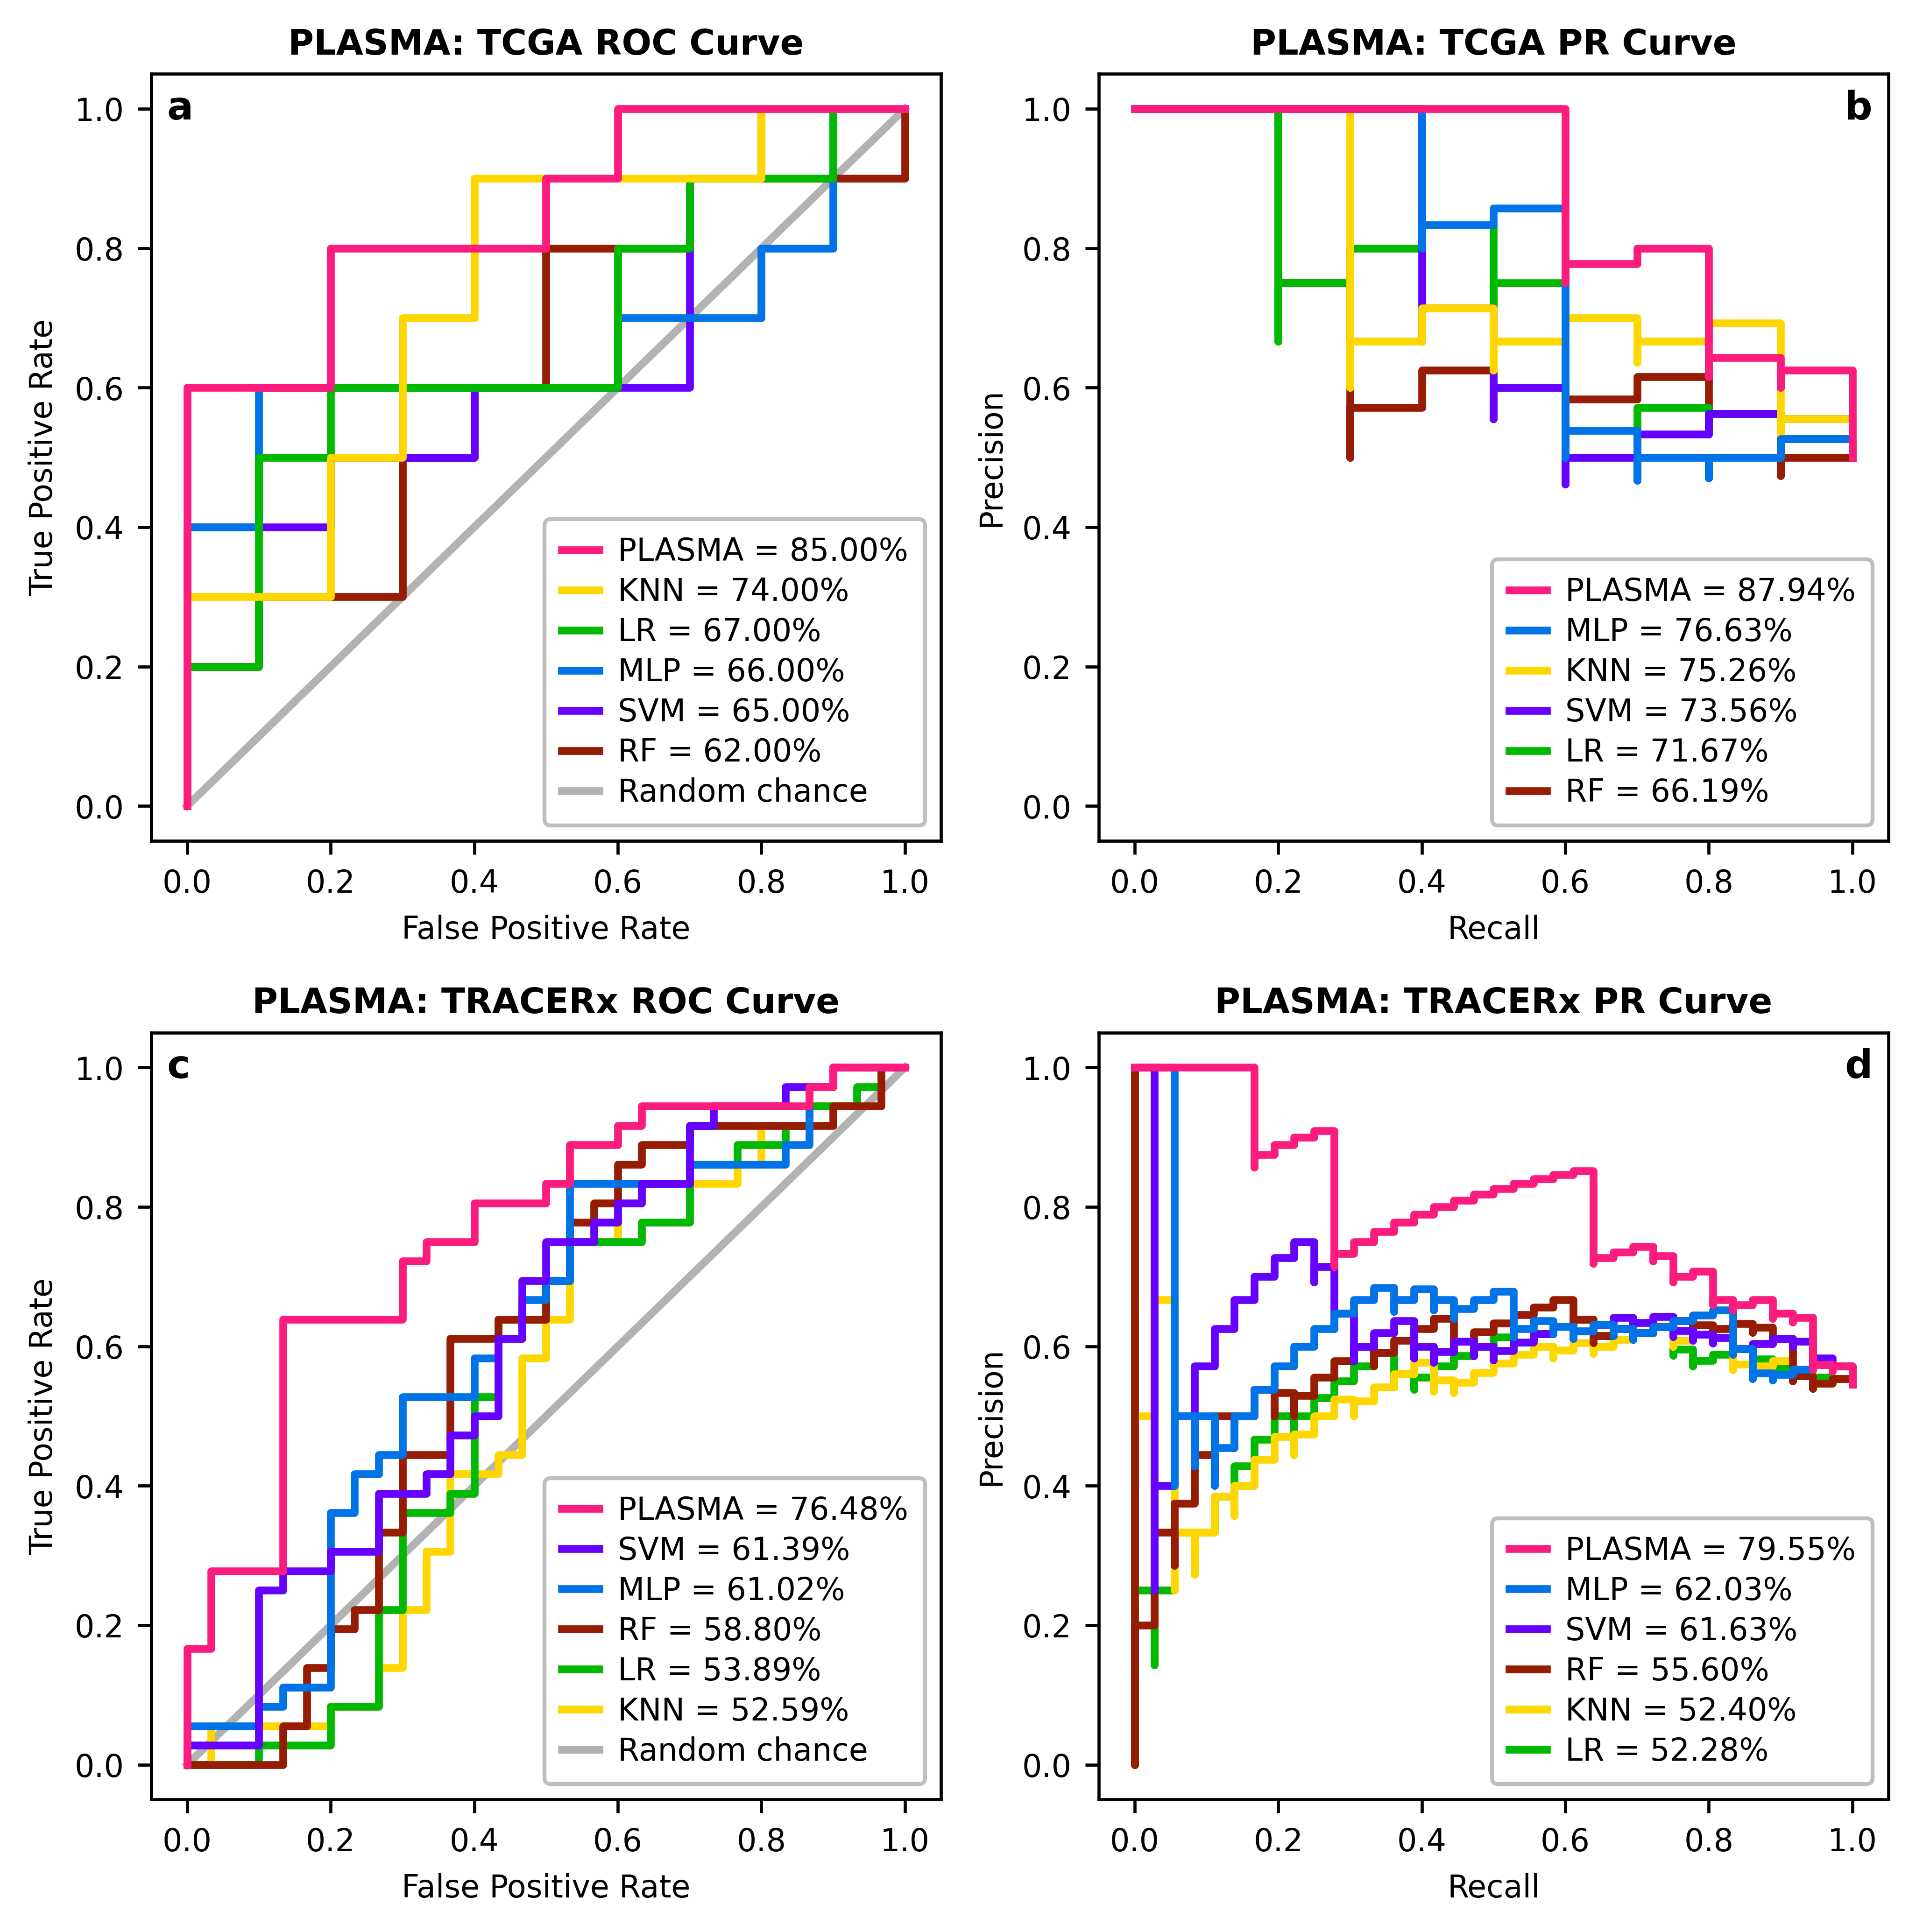

In [31]:
line_props = {
    'PLASMA': {'color': '#FC1C7D', 'lw': 2, 'solid_joinstyle': 'round'}, 
    'LR': {'color': '#02B902', 'lw': 2, 'solid_joinstyle': 'round'}, # 'dashes': [2, 1.7], 'dash_capstyle': 'round', 'dash_joinstyle': 'round'
    'RF': {'color': '#961C04', 'lw': 2, 'solid_joinstyle': 'round'}, # 'dashes': [3, 2, 2, 2], 'dash_capstyle': 'round', 'dash_joinstyle': 'round'
    'MLP': {'color': '#0073E6', 'lw': 2, 'solid_joinstyle': 'round'}, # 'dashes': [3, 2], 'dash_capstyle': 'round', 'dash_joinstyle': 'round', 'alpha':1
    'SVM': {'color': '#6600FF', 'lw': 2, 'solid_joinstyle': 'round'},
    'KNN': {'color': '#FFD700', 'lw': 2, 'solid_joinstyle': 'round'}, # 'dashes': [3, 1, 1, 1]
}

class plotML:
    def __init__(self, sd, line_props, names=None):
        self.formatted = {src: {k: sd[k]['results'][src]['metrics'] for k in ['PLASMA','LR','RF','MLP','SVM','KNN'] if k in sd} for src in ['tcga_test', 'tracerx']}
        self.line_props = line_props
        self.names = names
    
    def _plot_roc(self, ax, src, **kwargs):
        ax.plot([0, 1], [0, 1], color='#B2B2B2', lw=2, zorder=1, label='Random chance')
        for i, (m, v) in enumerate(self._sort_by_metric(self.formatted[src], 'auc').items()):
            style = {'color': '#CCCCCC', 'lw': 1.2, 'linestyle': '--'} if v.get('fallback', False) else self.line_props[m]
            lbl = f"{self._get_name(m, self.names)}{'*' if v.get('fallback', False) else ''} = {v['auc']*100:.2f}%"
            ax.step(v['fpr'], v['tpr'], **style, label=lbl, zorder=2+i)
        title = f"PLASMA: {dict(tcga_test='TCGA', tracerx='TRACERx')[src]} ROC Curve"
        self._housekeeping(ax, 'False Positive Rate', 'True Positive Rate', title, **kwargs)
    
    def _plot_pr(self, ax, src, **kwargs):
        for i, (m, v) in enumerate(self._sort_by_metric(self.formatted[src], 'auprc').items()):
            style = {'color': '#CCCCCC', 'lw': 1.2, 'linestyle': '--'} if v.get('fallback', False) else self.line_props[m]
            lbl = f"{self._get_name(m, self.names)}{'*' if v.get('fallback', False) else ''} = {v['auprc']*100:.2f}%"
            ax.step(v['prc_rec'], v['prc_prec'], where='post', **style, label=lbl, zorder=1+i)
        title = f"PLASMA: {dict(tcga_test='TCGA', tracerx='TRACERx')[src]} PR Curve"
        self._housekeeping(ax, 'Recall', 'Precision', title, **kwargs)

    def _housekeeping(self, ax, xlabel, ylabel, title, labelsize=8, titlesize=9):
        ax.set_ylim(-0.05, 1.05)
        ax.set_xlabel(xlabel, fontsize=labelsize, fontweight=540)
        ax.set_ylabel(ylabel, fontsize=labelsize, fontweight=540)
        ax.set_title(title, fontsize=titlesize, fontweight='bold', pad=5)
        ax.tick_params(axis='both', labelsize=labelsize)
        self._legend_in_axes(ax, loc='lower right', ncol=1)
    
    def _legend_in_axes(self, ax, loc='lower right', ncol=1):
        handles, labels = ax.get_legend_handles_labels()
        handles, labels = handles[::-1], labels[::-1] # reverse so best curves (sorted last) appear at bottom of legend
        leg = ax.legend(handles, labels, loc=loc, fontsize=8, ncol=ncol, frameon=True, fancybox=True, framealpha=0.85, edgecolor='0.7', handlelength=1.2, handletextpad=.6, labelspacing=.3, columnspacing=.8, borderpad=.55) # ncol=1 if len(labels) <= 6 else 2
        leg.set_zorder(10)
        return leg
    
    def _sort_by_metric(self, stats_dict, metric):
        return dict(sorted(stats_dict.items(), key=lambda it: (it[1][metric], it[0] == 'PLASMA'))) # ties: PLASMA last
    
    def _get_name(self, n, names=None):
        if names is None: return n
        return names[n]
    
    def roc_prc(self, fsize=(10, 8), dpi=1000, hspace=.2, **kwargs):
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=fsize, dpi=dpi, gridspec_kw={'hspace': hspace})
        for roc_ax, pr_ax, src in zip([ax1, ax3], [ax2, ax4], ['tcga_test', 'tracerx']):
            labels = ['a', 'b'] if src == 'tcga_test' else ['c', 'd']
            self._plot_roc(roc_ax, src, **kwargs)
            self._plot_pr(pr_ax, src, **kwargs)
            roc_ax.text(.02, 0.98, labels[0], transform=roc_ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='left', fontweight='bold')
            pr_ax.text(.98, 0.98, labels[1], transform=pr_ax.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', fontweight='bold')
        plt.show()

    def roc_only(self, fsize=(10, 4.8), dpi=600, **kwargs):
        fig, axs = plt.subplots(nrows=1, ncols=2, figsize=fsize, dpi=dpi)
        for src, ax in zip(['tcga_test', 'tracerx'], axs):
            self._plot_roc(ax, src, **kwargs)
        plt.show()

    def pr_only(self, fsize=(10, 4.8), dpi=600, **kwargs):
        fig, axs = plt.subplots(nrows=1, ncols=2, figsize=fsize, dpi=dpi)
        for src, ax in zip(['tcga_test', 'tracerx'], axs):
            self._plot_pr(ax, src, **kwargs)
        plt.show()

plotml = plotML(baseline_results, line_props)
plotml.roc_prc(fsize=(8, 8), hspace=.25, dpi=600)

In [32]:
ablation_dict = {'CEM': mte_final, 'C': mte_C, 'E': mte_E, 'M': mte_M, 'CE': mte_CE, 'CM': mte_CM, 'EM': mte_EM}

import ablation; importlib.reload(ablation)
from ablation import run_ablation_stats

In [ ]:
# ── Run + print ──────────────────────────────────────────────
# Analysis 1: per-variant "vs chance" — one-sided permutation, primary significance test
perm_dfs = run_ablation_stats(ablation_mtes=ablation_dict, n_permutations=1000, perm_seed=444)
print("── Permutation Tests (one-sided, AUC > 0.5) ─────────────────")
for split, df in perm_dfs.items():
    print(f"\n{split}")
    print(df.to_string())

── Permutation Tests (one-sided, AUC > 0.5) ─────────────────

TCGA Test
          n   auc  auc_ci_low  auc_ci_high  effect_size  p_raw  p_bonf  sig_bonf
version                                                                         
CEM      20  85.0       64.29        98.96         35.0  0.003   0.021      True
C        20  82.0       59.52        97.98         32.0  0.005   0.035      True
CE       20  68.0       42.41        90.11         18.0  0.100   0.700     False
E        20  63.0       36.36        87.88         13.0  0.204   1.000     False
M        20  49.0       22.00        76.57         -1.0  0.542   1.000     False
CM       20  36.0       11.00        63.74        -14.0  0.853   1.000     False
EM       20  23.0        4.17        46.88        -27.0  0.976   1.000     False

TracerX
          n    auc  auc_ci_low  auc_ci_high  effect_size  p_raw  p_bonf  sig_bonf
version                                                                          
CEM      66  76.48       

In [ ]:
just_concat = run_ablation_stats({'CEM': mte_final, 'CEM_concat': mte_concat}, n_permutations=1000, perm_seed=444)
for split, df in just_concat.items():
    print(f"\n{split}")
    print(df.to_string())


TCGA Test
             n   auc  auc_ci_low  auc_ci_high  effect_size  p_raw  p_bonf  sig_bonf
version                                                                            
CEM         20  85.0       64.29        98.96         35.0  0.003   0.006      True
CEM_concat  20  65.0       38.54        89.33         15.0  0.147   0.294     False

TracerX
             n    auc  auc_ci_low  auc_ci_high  effect_size  p_raw  p_bonf  sig_bonf
version                                                                             
CEM         66  76.48       64.20        87.42        26.48  0.000   0.000      True
CEM_concat  66  53.33       38.66        68.02         3.33  0.309   0.618     False
